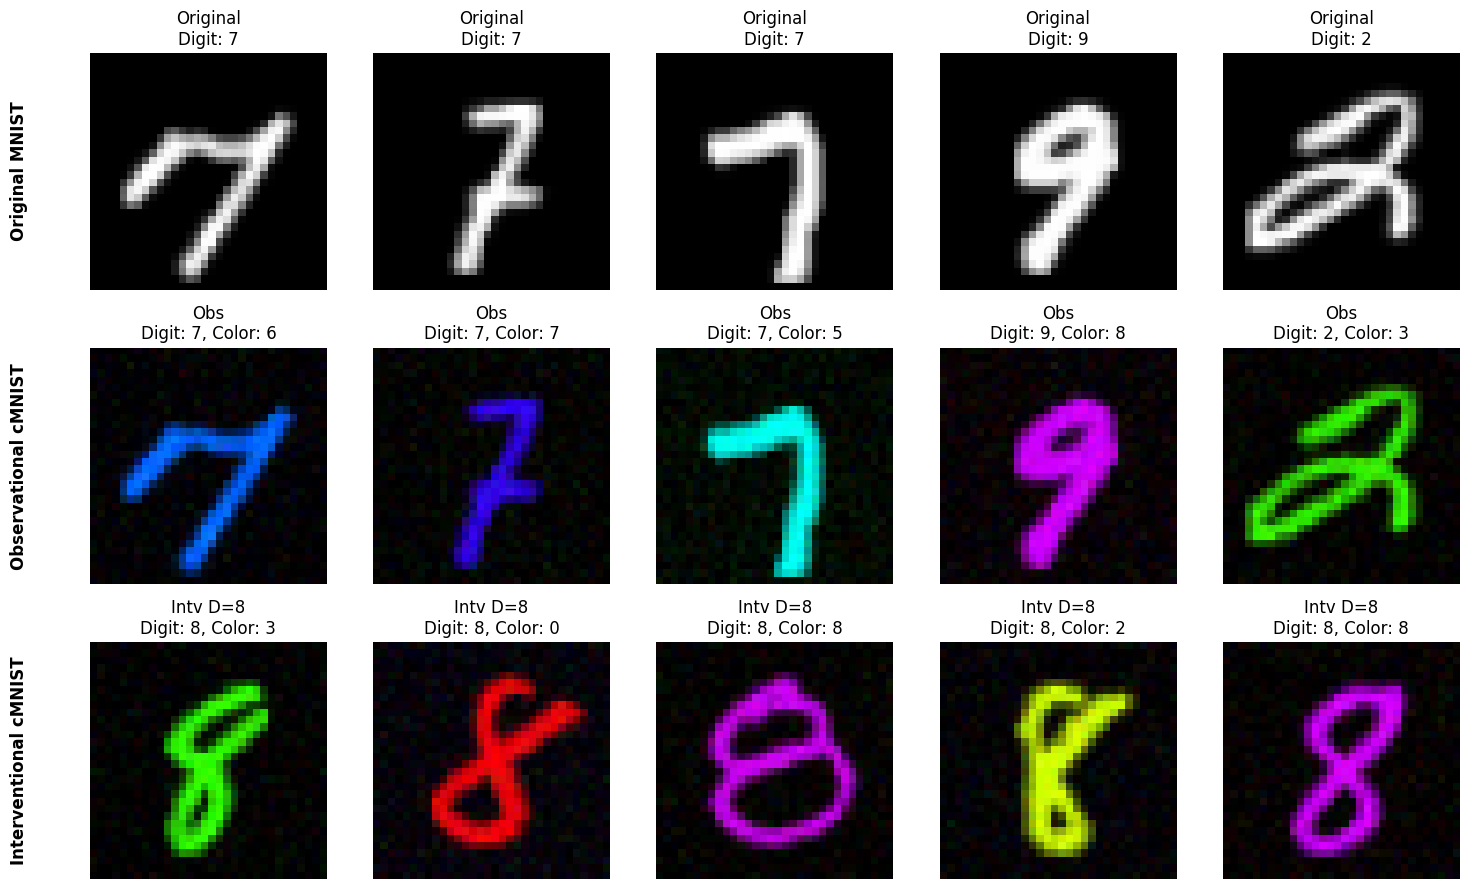

In [1]:
# === Inspect ColorMNIST Samples ===
import torch
import matplotlib.pyplot as plt
import os

# --- Load saved data ---
DATA_DIR = "data/cmnist"   # adjust if different
Dll_samples = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"))
omega_labels = torch.load(os.path.join(DATA_DIR, "intervention_mapping.pkl"))

# convenience aliases (for old-style code expecting None / Intervention)
Dll_samples[None] = Dll_samples.get("obs")
omega = {k: k for k in omega_labels.keys()}  # identity map for plotting

# --- Pick observational and one interventional dataset ---
obs_data = Dll_samples["obs"]
obs_images, obs_shapes, obs_digits, obs_colors = obs_data

iota1 = "D=8"   # choose any from INTERVENTION_LABELS
int_data = Dll_samples[iota1]
int_images, int_shapes, int_digits, int_colors = int_data

# --- Plot ---
n_samples = 5
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for i in range(n_samples):
    # Row 1: original MNIST grayscale
    shape = obs_shapes[i].squeeze()
    axes[0, i].imshow((shape + 1) / 2, cmap="gray")  # convert [-1,1] → [0,1]
    axes[0, i].set_title(f"Original\nDigit: {obs_digits[i].item()}")
    axes[0, i].axis("off")

    # Row 2: observational colored
    img = obs_images[i].permute(1, 2, 0).clamp(0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Obs\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}")
    axes[1, i].axis("off")

    # Row 3: interventional colored
    int_img = int_images[i].permute(1, 2, 0).clamp(0, 1)
    axes[2, i].imshow(int_img)
    axes[2, i].set_title(f"Intv {iota1}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}")
    axes[2, i].axis("off")

# --- Row labels ---
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


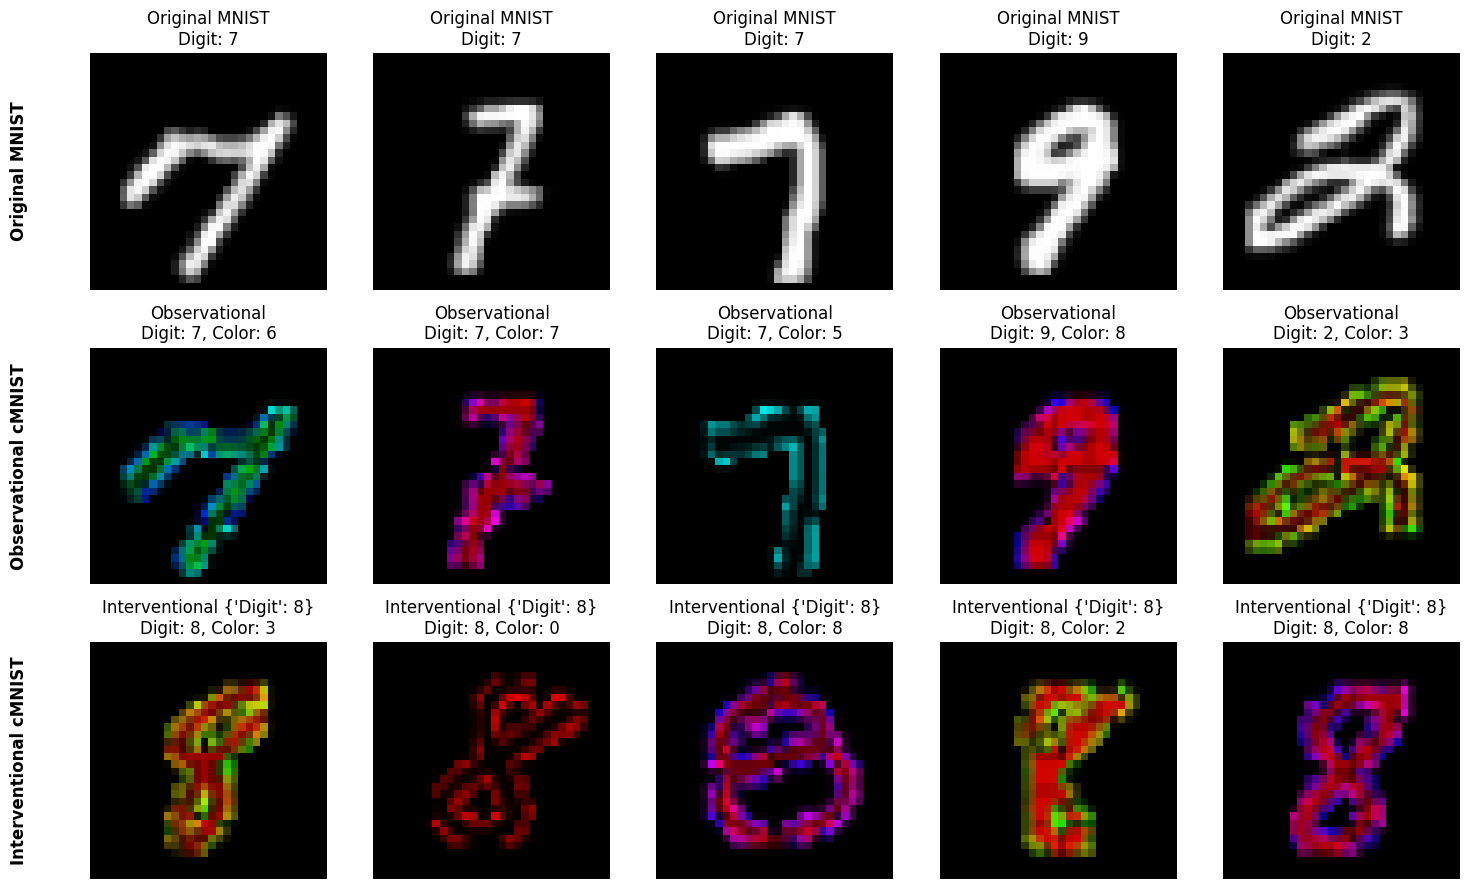

In [1]:
# === Inspect ColorMNIST Samples (Generator 1 version) ===
import torch
import matplotlib.pyplot as plt
import os

# --- Load saved data (with Intervention objects as keys) ---
DATA_DIR = "data/cmnist"  # adjust if needed
Dll_samples = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"))
Dhl_samples = torch.load(os.path.join(DATA_DIR, "dhl_samples.pkl"))
omega = torch.load(os.path.join(DATA_DIR, "intervention_mapping.pkl"))

# --- Pick observational and one interventional dataset ---
obs_data = Dll_samples[None]                 # Observational samples
obs_images, obs_shapes, obs_digits, obs_colors = obs_data

# Pick one interventional key (you can also filter by .vv())
iota1 = list(omega.keys())[2]                # for example, the third intervention
int_data = Dll_samples[iota1]
int_images, int_shapes, int_digits, int_colors = int_data

# --- Plot visualization grid ---
n_samples = 5
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for i in range(n_samples):
    # Row 1: Original MNIST grayscale
    shape = obs_shapes[i].squeeze()  # (H,W)
    axes[0, i].imshow((shape + 1) / 2, cmap='gray')  # [-1,1] → [0,1]
    axes[0, i].set_title(f"Original MNIST\nDigit: {obs_digits[i].item()}")
    axes[0, i].axis("off")

    # Row 2: Observational colored images
    img = obs_images[i].permute(1, 2, 0).clamp(0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Observational\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}")
    axes[1, i].axis("off")

    # Row 3: Interventional colored images
    int_img = int_images[i].permute(1, 2, 0).clamp(0, 1)
    axes[2, i].imshow(int_img)
    axes[2, i].set_title(f"Interventional {iota1.vv()}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}")
    axes[2, i].axis("off")

# --- Row labels ---
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Loaded:
  - 10 LL intervention sets
  - 10 HL intervention sets
  - intervention labels: ['obs', 'D=6', 'D=8', 'D=4', 'C=7', 'C=0', 'C=4', 'D=6,C=7', 'D=8,C=0', 'D=4,C=4']


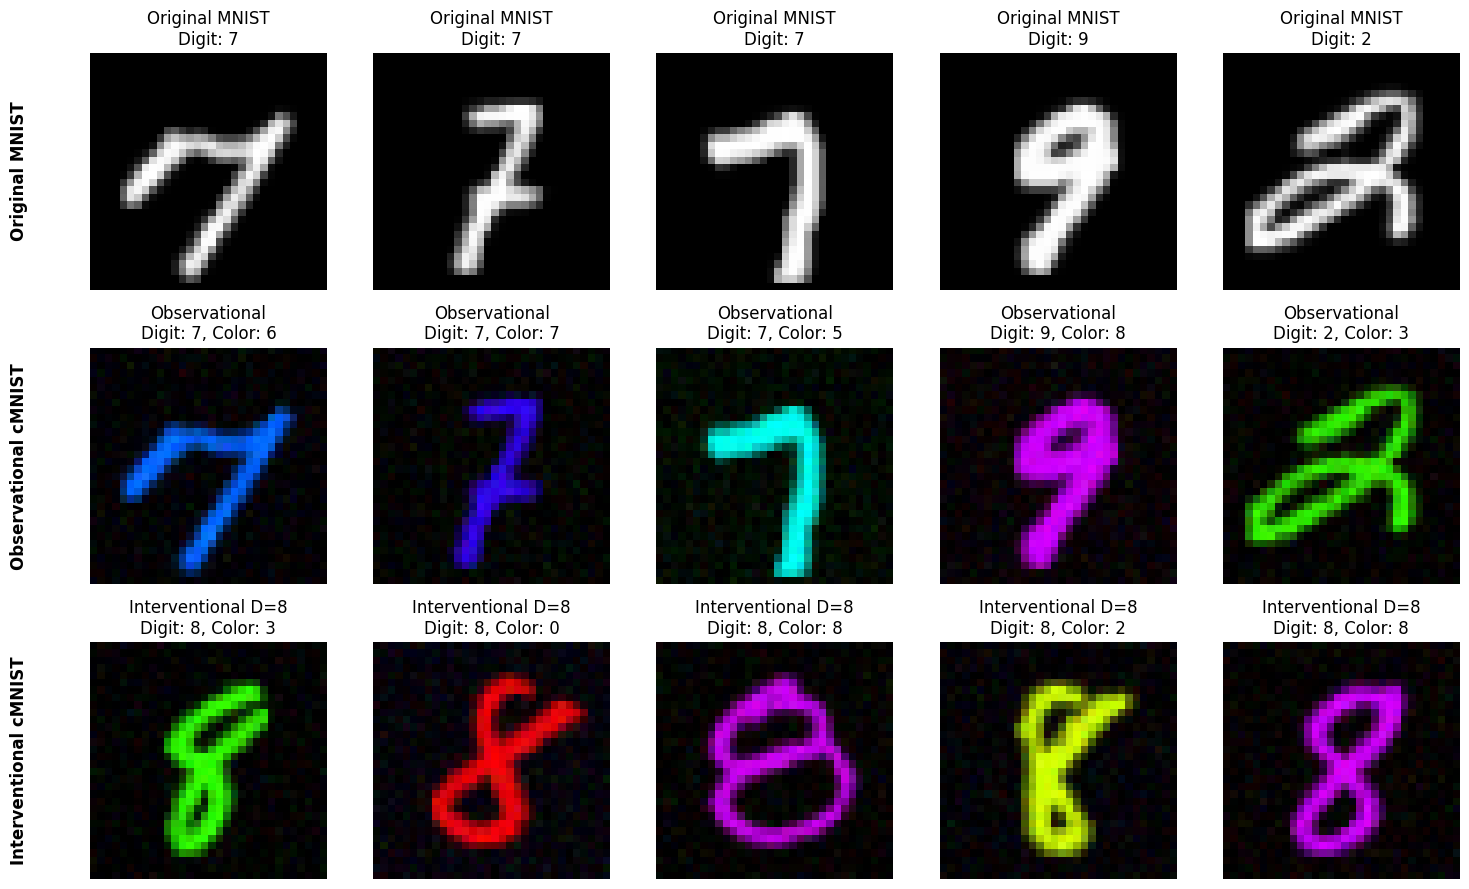

In [1]:
import torch
import matplotlib.pyplot as plt
from operations import Intervention  # same class as used before

# --- Paths ---
DATA_DIR = 'data/cmnist'  # adjust if you used a custom output_dir

# --- Load saved data ---
Dll_samples = torch.load(f"{DATA_DIR}/dll_samples.pkl")
Dhl_samples = torch.load(f"{DATA_DIR}/dhl_samples.pkl")
omega_labels = torch.load(f"{DATA_DIR}/intervention_mapping.pkl")

print("Loaded:")
print(f"  - {len(Dll_samples)} LL intervention sets")
print(f"  - {len(Dhl_samples)} HL intervention sets")
print(f"  - intervention labels:", list(omega_labels.keys()))

# --- Inspect one observational and one interventional sample set ---
obs_data = Dll_samples["obs"]
obs_images, obs_shapes, obs_digits, obs_colors = obs_data

# pick one intervention, e.g., "D=8" or "D=6,C=7"
chosen_label = "D=8"
int_data = Dll_samples[chosen_label]
int_images, int_shapes, int_digits, int_colors = int_data

n_samples = 5
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for i in range(n_samples):
    # Row 1: Original MNIST shapes (grayscale)
    shape = obs_shapes[i].squeeze()  # remove channel dim
    axes[0, i].imshow((shape + 1) / 2, cmap='gray')  # back to [0,1]
    axes[0, i].set_title(f'Original MNIST\nDigit: {obs_digits[i].item()}')
    axes[0, i].axis('off')

    # Row 2: Observational colored images
    img = obs_images[i].permute(1, 2, 0).clip(0, 1)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Observational\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}')
    axes[1, i].axis('off')

    # Row 3: Interventional colored images
    int_img = int_images[i].permute(1, 2, 0).clip(0, 1)
    axes[2, i].imshow(int_img)
    axes[2, i].set_title(f'Interventional {chosen_label}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}')
    axes[2, i].axis('off')

# Add row labels
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [2]:
import torch

# Select two draws of the same (digit, color)
obs_images, _, obs_digits, obs_colors = Dll_samples["obs"]
mask_7 = (obs_digits == 7) & (obs_colors == 6)
subset = obs_images[mask_7][:10]  # take up to 10 samples of that pair

# Compute per-pixel variance across these 10 samples
pixel_var = subset.var(dim=0).mean().item()
print(f"Mean pixel variance across same (digit=7, color=6): {pixel_var:.6f}")


Mean pixel variance across same (digit=7, color=6): 0.013185


Loading and preparing MNIST dataset...
MNIST dataset ready.
Same-base noise: mean pixel variance = 0.000393 (std ≈ 0.0188)


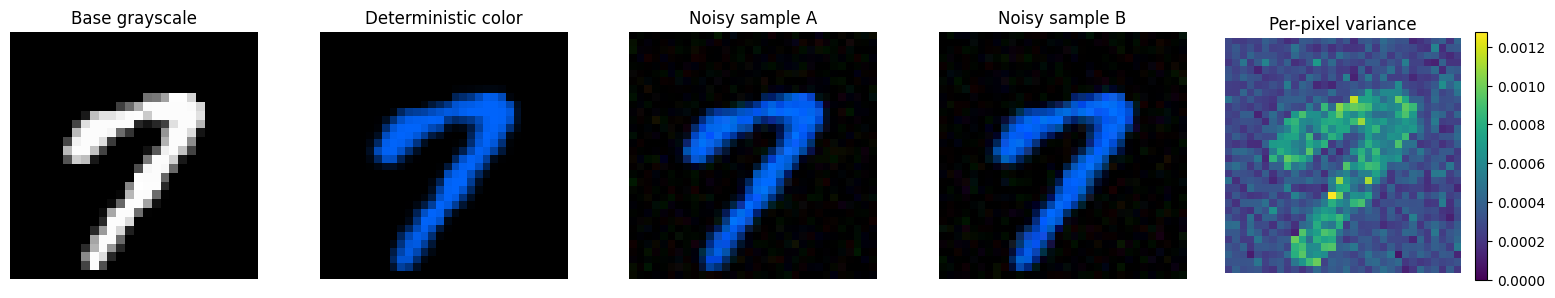

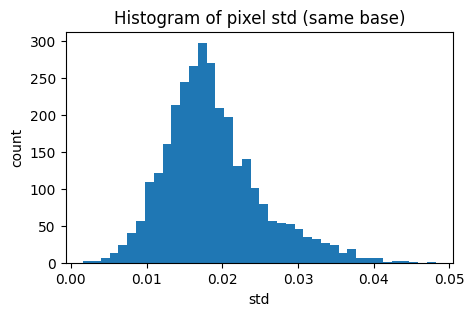

In [4]:
import torch, numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF

# import your generator module (adjust name/path if different)
import cmnist_data_generator as genmod

# Recreate the generator so we can access its internals
gen = genmod.ColorMNISTDataGenerator(image_size=genmod.RESOLUTION, correlation=genmod.CORRELATION)

digit = 7
color = 6
idx   = 0  # pick a specific MNIST '7' (try different indices to see other shapes)

base_u8 = gen.mnist_data[digit][idx]            # uint8 (H0, W0)
base_shape = gen.shape_transform(base_u8)       # (1,H,W) in [-1,1] if you want it
r,g,b = gen.colors[color]

def colorize_once(u8, r,g,b, add_noise=True):
    # grayscale -> [0,1]
    img01 = (u8.to(torch.float32) / 255.0).unsqueeze(0)      # (1,H0,W0)
    rgb   = img01.repeat(3,1,1)                              # (3,H0,W0)
    rgb[0].mul_(r); rgb[1].mul_(g); rgb[2].mul_(b)
    out = TF.resize(rgb, [gen.image_size, gen.image_size], antialias=True)  # [0,1]
    if add_noise:
        sigma = getattr(genmod, "SENSOR_NOISE_STD", 0.03)
        noise = torch.randn_like(out) * sigma
        out = (out + noise).clamp(0.0, 1.0)
    return out

# Make K noisy replicas of *the same* base image & color
K = 16
replicas = torch.stack([colorize_once(base_u8, r,g,b, add_noise=True) for _ in range(K)], dim=0)  # (K,3,H,W)

# Compute per-pixel std and overall mean variance
pix_var = replicas.var(dim=0)                # (3,H,W)
mean_var = pix_var.mean().item()
mean_std = pix_var.sqrt().mean().item()
print(f"Same-base noise: mean pixel variance = {mean_var:.6f} (std ≈ {mean_std:.4f})")
# For SENSOR_NOISE_STD=0.03 you should see var ≈ 0.0009 and std ≈ 0.03

# Visualize: one clean colorization, two noisy draws, their difference, and variance map
clean   = colorize_once(base_u8, r,g,b, add_noise=False)
a, b_   = replicas[0], replicas[1]
diff    = (a - b_).abs().mean(0)             # (3,H,W) mean abs diff across channels
varmap  = pix_var.mean(0)                    # (H,W)

fig, axs = plt.subplots(1,5, figsize=(16,3))
axs[0].imshow(base_u8.numpy(), cmap='gray'); axs[0].set_title("Base grayscale"); axs[0].axis('off')
axs[1].imshow(clean.permute(1,2,0));         axs[1].set_title("Deterministic color"); axs[1].axis('off')
axs[2].imshow(a.permute(1,2,0));             axs[2].set_title("Noisy sample A"); axs[2].axis('off')
axs[3].imshow(b_.permute(1,2,0));            axs[3].set_title("Noisy sample B"); axs[3].axis('off')
im = axs[4].imshow(varmap.numpy(), vmin=0, vmax=varmap.max()); axs[4].set_title("Per-pixel variance"); axs[4].axis('off')
plt.colorbar(im, ax=axs[4]); plt.tight_layout(); plt.show()

# Histogram of per-pixel std
plt.figure(figsize=(5,3))
plt.hist(pix_var.sqrt().flatten().numpy(), bins=40)
plt.title("Histogram of pixel std (same base)"); plt.xlabel("std"); plt.ylabel("count")
plt.show()


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import numpy as np
import matplotlib.pyplot as plt
from operations import Intervention
import os
from train_cmnist_models import ImageColorizerUNet

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Load the generated ColorMNIST data
data_dir = 'data/cmnist'

# Load the data
Dll_samples = torch.load(f'{data_dir}/dll_samples.pkl')
Dhl_samples = torch.load(f'{data_dir}/dhl_samples.pkl')
omega       = torch.load(f'{data_dir}/intervention_mapping.pkl')

# Load low-level U-Net model
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth')
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# Load high-level linear model
hl_model = joblib.load(f'{data_dir}/hl_model.joblib')

U_hl_hat = torch.load(f'{data_dir}/U_hl_hat.pkl')

print("Data loaded successfully!")
print(f"  - Low-level noise shape: {U_ll_hat.shape}")
print(f"  - High-level noise shape: {U_hl_hat.shape}")

RuntimeError: Error(s) in loading state_dict for ImageColorizerUNet:
	Unexpected key(s) in state_dict: "cls_head.2.weight", "cls_head.2.bias". 

In [16]:
# Dll_samples = torch.load("data/cmnist/dll_samples.pkl")
# Dhl_samples = torch.load("data/cmnist/dhl_samples.pkl")


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# HL variable names
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

def hl_last_col(t):
    """Return the HL Image_ column (mean pixel intensity)."""
    return t[:, -1].numpy()

def get(label):
    """Fetch a split from Dhl_samples by its string label (gen2)."""
    if label not in Dhl_samples:
        raise KeyError(f"Label {label!r} not in Dhl_samples. "
                       f"Available: {list(Dhl_samples.keys())[:10]} ...")
    return Dhl_samples[label]


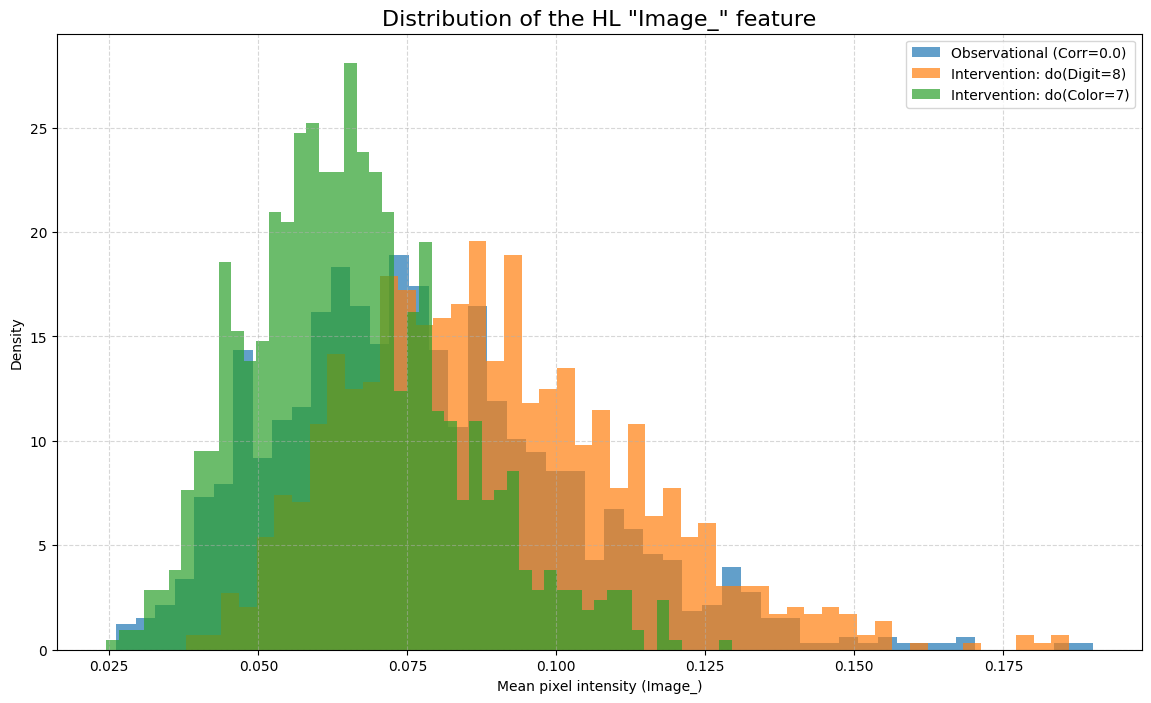

--- Distribution Statistics for HL 'Image_' ---

Observational:
  Mean: 0.0782 | Std: 0.0253 | Min: 0.0261 | Max: 0.1900

Intervention do(Digit=8):
  Mean: 0.0893 | Std: 0.0240

Intervention do(Color=7):
  Mean: 0.0657 | Std: 0.0173


In [4]:
# 1) distributions of HL "Image_" under obs, do(D=8), do(C=7)

obs_averages      = hl_last_col(get("obs"))
int_digit8_avgs   = hl_last_col(get("D=8"))
int_color7_avgs   = hl_last_col(get("C=7"))

plt.figure(figsize=(14, 8))
plt.hist(obs_averages,     bins=50, alpha=0.70, density=True, label='Observational (Corr=0.0)')
plt.hist(int_digit8_avgs,  bins=50, alpha=0.70, density=True, label='Intervention: do(Digit=8)')
plt.hist(int_color7_avgs,  bins=50, alpha=0.70, density=True, label='Intervention: do(Color=7)')
plt.title('Distribution of the HL "Image_" feature', fontsize=16)
plt.xlabel('Mean pixel intensity (Image_)'); plt.ylabel('Density'); plt.grid(ls='--', alpha=0.5); plt.legend()
plt.show()

print("--- Distribution Statistics for HL 'Image_' ---")
print("\nObservational:")
print(f"  Mean: {obs_averages.mean():.4f} | Std: {obs_averages.std():.4f} | "
      f"Min: {obs_averages.min():.4f} | Max: {obs_averages.max():.4f}")

print("\nIntervention do(Digit=8):")
print(f"  Mean: {int_digit8_avgs.mean():.4f} | Std: {int_digit8_avgs.std():.4f}")

print("\nIntervention do(Color=7):")
print(f"  Mean: {int_color7_avgs.mean():.4f} | Std: {int_color7_avgs.std():.4f}")


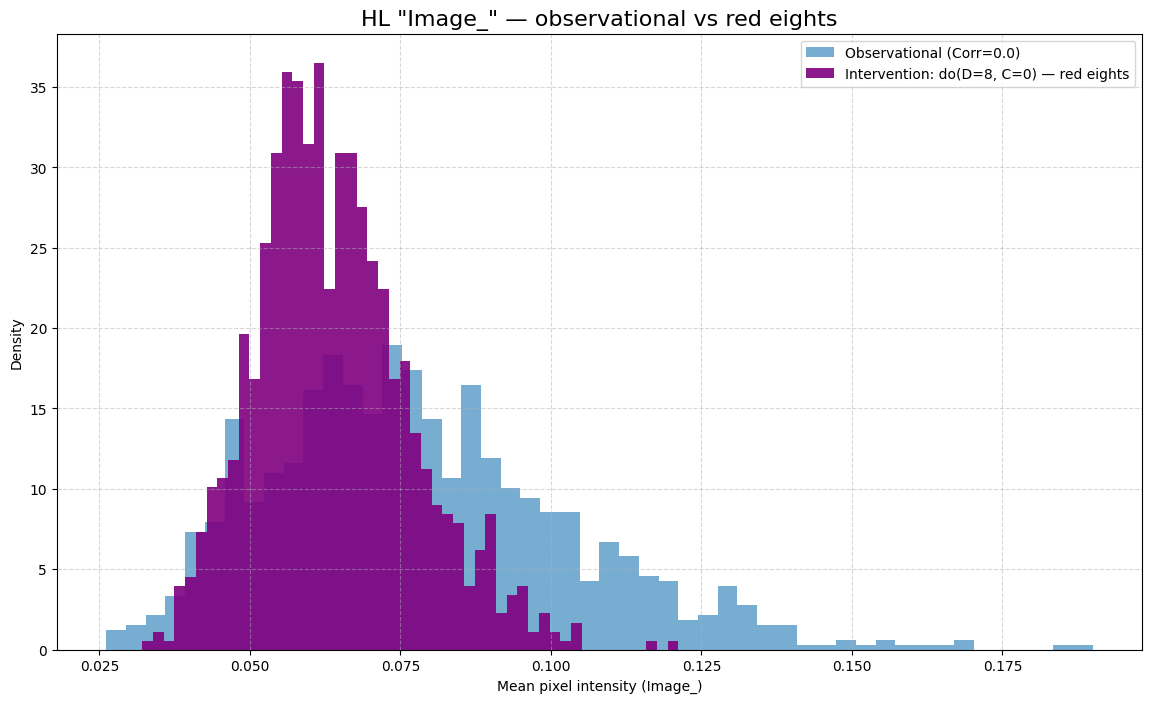

--- Distribution Statistics ---

Observational:
  Mean: 0.0782 | Std: 0.0253

Intervention do(D=8, C=0):
  Mean: 0.0639 | Std: 0.0129


In [5]:
# 2) obs vs do(D=8,C=0) — "red eights"

obs_averages        = hl_last_col(get("obs"))
int_d8_c0_averages  = hl_last_col(get("D=8,C=0"))

plt.figure(figsize=(14, 8))
plt.hist(obs_averages,       bins=50, alpha=0.60, density=True, label='Observational (Corr=0.0)')
plt.hist(int_d8_c0_averages, bins=50, alpha=0.90, density=True, label='Intervention: do(D=8, C=0) — red eights', color='purple')
plt.title('HL "Image_" — observational vs red eights', fontsize=16)
plt.xlabel('Mean pixel intensity (Image_)'); plt.ylabel('Density'); plt.grid(ls='--', alpha=0.5); plt.legend()
plt.show()

print("--- Distribution Statistics ---")
print("\nObservational:")
print(f"  Mean: {obs_averages.mean():.4f} | Std: {obs_averages.std():.4f}")
print("\nIntervention do(D=8, C=0):")
print(f"  Mean: {int_d8_c0_averages.mean():.4f} | Std: {int_d8_c0_averages.std():.4f}")


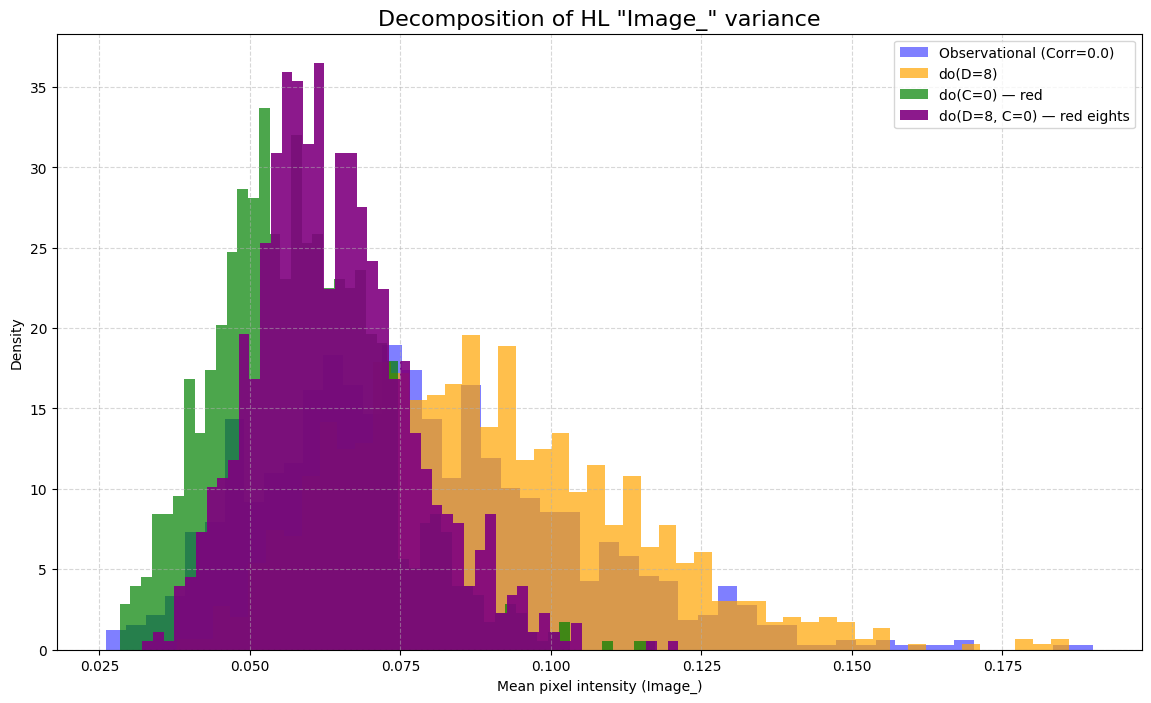

--- Distribution Statistics for HL 'Image_' ---

Observational (total variance):
  Mean: 0.0782 | Std: 0.0253

Intervention do(D=8): (variation from color)
  Mean: 0.0893 | Std: 0.0240

Intervention do(C=0): (variation from digit)
  Mean: 0.0585 | Std: 0.0140

do(D=8, C=0): (residual/base noise)
  Mean: 0.0639 | Std: 0.0129


In [6]:
# 3) four-way comparison

obs_averages       = hl_last_col(get("obs"))
int_digit8_avgs    = hl_last_col(get("D=8"))
int_color0_avgs    = hl_last_col(get("C=0"))
int_d8_c0_averages = hl_last_col(get("D=8,C=0"))

plt.figure(figsize=(14, 8))
plt.hist(obs_averages,       bins=50, alpha=0.50, density=True, label='Observational (Corr=0.0)', color='blue')
plt.hist(int_digit8_avgs,    bins=50, alpha=0.70, density=True, label='do(D=8)', color='orange')
plt.hist(int_color0_avgs,    bins=50, alpha=0.70, density=True, label='do(C=0) — red', color='green')
plt.hist(int_d8_c0_averages, bins=50, alpha=0.90, density=True, label='do(D=8, C=0) — red eights', color='purple')
plt.title('Decomposition of HL "Image_" variance', fontsize=16)
plt.xlabel('Mean pixel intensity (Image_)'); plt.ylabel('Density'); plt.grid(ls='--', alpha=0.5); plt.legend()
plt.show()

print("--- Distribution Statistics for HL 'Image_' ---")
print("\nObservational (total variance):")
print(f"  Mean: {obs_averages.mean():.4f} | Std: {obs_averages.std():.4f}")

print("\nIntervention do(D=8): (variation from color)")
print(f"  Mean: {int_digit8_avgs.mean():.4f} | Std: {int_digit8_avgs.std():.4f}")

print("\nIntervention do(C=0): (variation from digit)")
print(f"  Mean: {int_color0_avgs.mean():.4f} | Std: {int_color0_avgs.std():.4f}")

print("\ndo(D=8, C=0): (residual/base noise)")
print(f"  Mean: {int_d8_c0_averages.mean():.4f} | Std: {int_d8_c0_averages.std():.4f}")


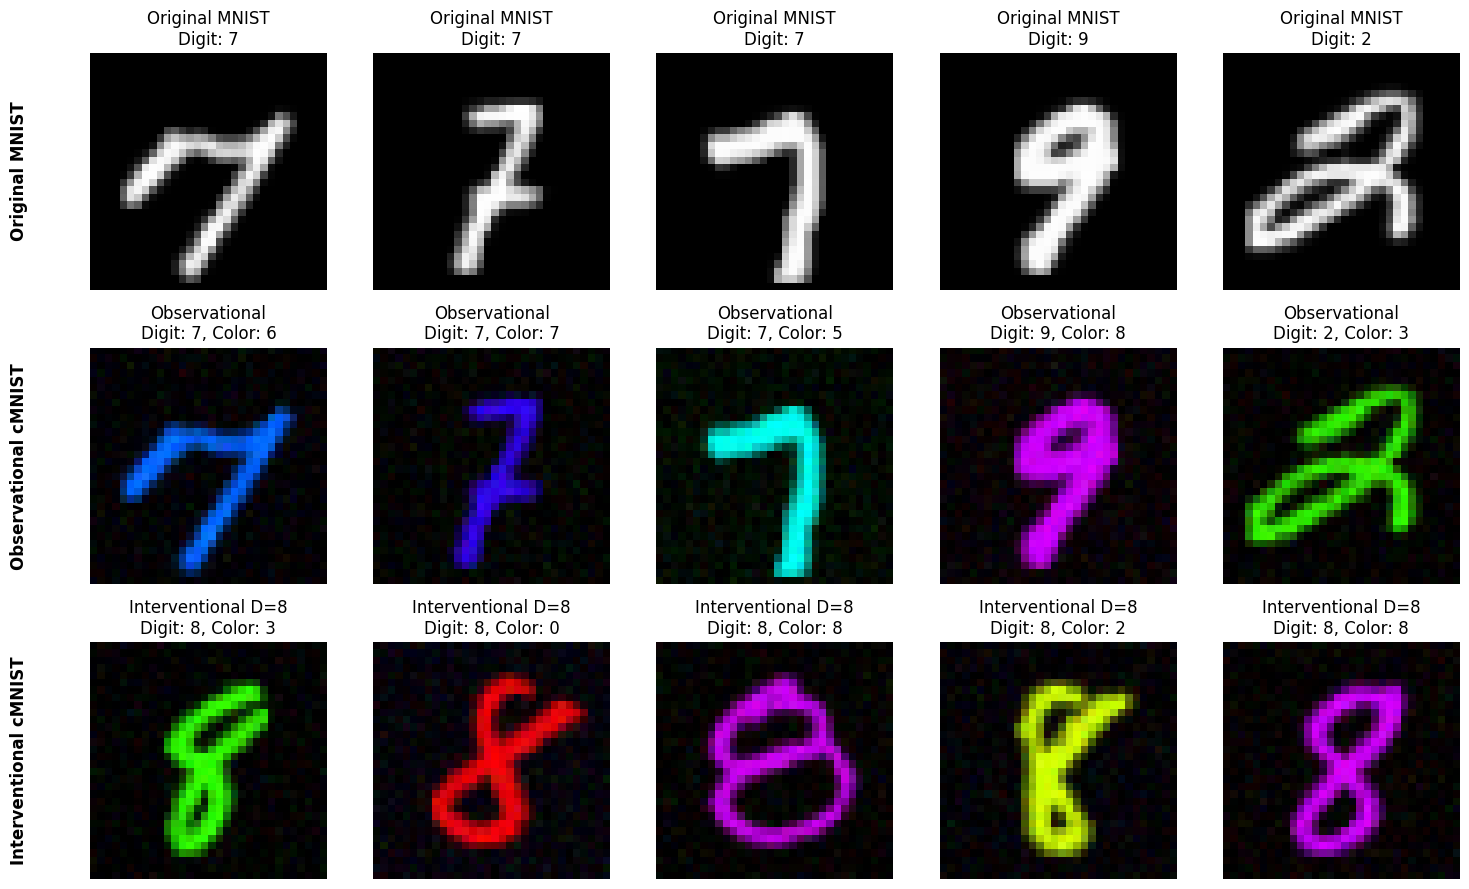

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# choose which intervention row to show (e.g., "D=8", "C=7", "D=8,C=0", etc.)
INT_LABEL = "D=8"

# get observational and interventional batches
obs_images, obs_shapes, obs_digits, obs_colors = Dll_samples["obs"]
int_images, int_shapes, int_digits, int_colors = Dll_samples[INT_LABEL]

# how many columns to show
n_samples = 5
idxs = np.arange(min(n_samples, len(obs_images)))  # first n; or: np.random.choice(len(obs_images), n_samples, replace=False)

fig, axes = plt.subplots(3, len(idxs), figsize=(3*len(idxs), 9))

for col, i in enumerate(idxs):
    # ---- Row 1: Original MNIST shapes (grayscale in [-1,1]) -> map to [0,1] for display
    shape = ((obs_shapes[i].squeeze().cpu().numpy()) + 1.0) / 2.0
    axes[0, col].imshow(shape, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'Original MNIST\nDigit: {obs_digits[i].item()}')
    axes[0, col].axis('off')

    # ---- Row 2: Observational colored images (CHW [0,1] -> HWC)
    img_obs = obs_images[i].permute(1, 2, 0).cpu().numpy()
    axes[1, col].imshow(img_obs)
    axes[1, col].set_title(f'Observational\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}')
    axes[1, col].axis('off')

    # ---- Row 3: Interventional colored images (using INT_LABEL)
    img_int = int_images[i].permute(1, 2, 0).cpu().numpy()
    axes[2, col].imshow(img_int)
    axes[2, col].set_title(f'Interventional {INT_LABEL}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}')
    axes[2, col].axis('off')

# Row labels on the left
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Helper: get the observational split regardless of keying style
def _get_obs_tuple(D):
    return D.get("obs") or D.get(None) or next(iter(D.values()))

ll_obs_data_tuple = _get_obs_tuple(Dll_samples)   # (images, shapes, digits, colors)
hl_obs_data      = Dhl_samples.get("obs", next(iter(Dhl_samples.values())))

print("Observational data defined:")
print(f"  - Low-level shape: {ll_obs_data_tuple[0].shape} (images)")
print(f"  - High-level shape: {hl_obs_data.shape}")


Observational data defined:
  - Low-level shape: torch.Size([1000, 3, 32, 32]) (images)
  - High-level shape: torch.Size([1000, 21])


In [9]:
def comprehensive_counterfactual_diagnostics(ll_obs_data_tuple, ll_model_unet, U_ll_hat_unet, 
                                             num_samples=5, bins=36, v_thresh=0.1):
    """
    Comprehensive diagnostics for counterfactual analysis including:
    1) Residual diagnostics (independence, distribution)
    2) Counterfactual consistency scores
    3) Color hue analysis
    4) Visual counterfactual sweep
    """
    print("=" * 60)
    print("COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS")
    print("=" * 60)

    # Unpack data
    final_images, img_shapes, digits, colors = ll_obs_data_tuple

    # ===== 1. RESIDUAL DIAGNOSTICS =====
    print("\n1. RESIDUAL DIAGNOSTICS")
    print("-" * 30)

    U = U_ll_hat_unet.view(U_ll_hat_unet.size(0), -1).detach().cpu().numpy()

    # Sample pixels for analysis
    rng = np.random.default_rng(0)
    sample_pixels = rng.choice(U.shape[1], size=num_samples, replace=False)
    resid_samples = U[:, sample_pixels]

    # Histogram check
    fig, axs = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        axs[i].hist(resid_samples[:, i], bins=40, alpha=0.7)
        axs[i].set_title(f"Pixel {sample_pixels[i]}")
    plt.suptitle("Residual distributions (sampled pixels)")
    plt.tight_layout()
    plt.show()

    # Dependence check
    digits_np = digits.cpu().numpy()
    colors_np = colors.cpu().numpy()
    X = np.stack([digits_np, colors_np], axis=1)

    y = resid_samples[:, 0]
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)
    r2_resid = r2_score(y, y_pred)

    print(f"R² of predicting residual (pixel {sample_pixels[0]}) from labels: {r2_resid:.4f}")
    if abs(r2_resid) < 0.05:
        print("✓ Residual appears independent of labels (good exogenous noise).")
    else:
        print("⚠ Residual still has label-dependent structure.")

    # Visual sanity check (convert safely to [0,1] for display)
    def to01_any(x):
        x = x.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()

    idx = np.random.randint(0, len(U_ll_hat_unet))
    resid_img = to01_any(U_ll_hat_unet[idx]).transpose(1,2,0)
    true_img  = to01_any(final_images[idx]).transpose(1,2,0)
    pred_img  = np.clip(true_img - resid_img, 0.0, 1.0)

    fig, axs = plt.subplots(1, 3, figsize=(9,3))
    axs[0].imshow(true_img); axs[0].set_title("True image")
    axs[1].imshow(pred_img); axs[1].set_title("Predicted deterministic")
    axs[2].imshow(resid_img); axs[2].set_title("Residual (noise)")
    for ax in axs: ax.axis("off")
    plt.tight_layout(); plt.show()

    # ===== 2. COUNTERFACTUAL CONSISTENCY SCORES =====
    print("\n2. COUNTERFACTUAL CONSISTENCY SCORES")
    print("-" * 40)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ll_model_unet = ll_model_unet.to(device).eval()

    idx = np.random.randint(0, len(U_ll_hat_unet))
    with torch.no_grad():
        base_shape = img_shapes[idx:idx+1].to(device)
        base_digit = digits[idx:idx+1].to(device)
        U_fixed    = U_ll_hat_unet[idx:idx+1].to(device)

        dets, outs = [], []
        for c in range(10):
            c_tensor = torch.tensor([c], device=device)
            det = ll_model_unet(base_shape, base_digit, c_tensor)
            ycf = det + U_fixed
            dets.append(det.cpu())
            outs.append(ycf.cpu())

    D = torch.stack(dets, dim=0)  # (10,1,3,H,W)
    O = torch.stack(outs, dim=0)  # (10,1,3,H,W)

    # Digit shape invariance (use gray proxy as mean across RGB)
    D_gray = D.mean(2)            # (10,1,H,W)
    var_digit = D_gray.var(0).mean().item()

    # Color sensitivity: mean brightness over pixels for each c
    mean_colors = O.view(O.size(0), O.size(1), -1).mean(-1)
    var_color = mean_colors.var(0).mean().item()

    # Noise stability across colors for fixed U
    U_cmp = O - D
    U_flat = U_cmp.view(U_cmp.size(0), -1).cpu().numpy()  # (10, HW*3)
    corr_mat = np.corrcoef(U_flat)
    mean_corr = (corr_mat[np.triu_indices_from(corr_mat, k=1)]).mean()

    consistency_scores = {
        "digit_variance": var_digit,
        "color_variance": var_color,
        "noise_corr": mean_corr
    }
    print("Consistency Scores:")
    for k,v in consistency_scores.items():
        print(f"  {k}: {v:.6f}")

    # ===== 3. COLOR HUE ANALYSIS =====
    print("\n3. COLOR HUE ANALYSIS")
    print("-" * 25)

    def hue_hist(img_chw, bins=36, v_thresh=0.1):
        x = img_chw.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1) / 2
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        rgb = x.permute(1,2,0).numpy()
        hsv = rgb_to_hsv(rgb)
        H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]
        mask = V > v_thresh
        if mask.sum() == 0:
            return np.ones(bins) / bins
        h = H[mask].ravel()
        hist, _ = np.histogram(h, bins=bins, range=(0,1), density=False)
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-12
        return hist

    def js_divergence(p, q):
        m = 0.5*(p+q)
        def kl(a,b):
            a = np.clip(a, 1e-12, 1.0)
            b = np.clip(b, 1e-12, 1.0)
            return np.sum(a * np.log(a/b))
        return 0.5*kl(p,m) + 0.5*kl(q,m)

    def color_hue_js_score(dets, bins=36, v_thresh=0.25):
        Hs = [hue_hist(det[0], bins=bins, v_thresh=v_thresh) for det in dets]
        js_vals = [js_divergence(Hs[i], Hs[j]) for i in range(len(Hs)) for j in range(i+1, len(Hs))]
        return float(np.mean(js_vals)) if js_vals else 0.0

    js_hue = color_hue_js_score(dets, bins=bins, v_thresh=v_thresh)
    print(f"Mean pairwise JS divergence over hue histograms: {js_hue:.4f}")

    # ===== 4. VISUAL COUNTERFACTUAL SWEEP =====
    print("\n4. VISUAL COUNTERFACTUAL SWEEP")
    print("-" * 35)

    def to01(img_t):
        x = img_t.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()

    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for c in range(10):
        axs[0, c].imshow(to01(dets[c][0].permute(1,2,0))); axs[0, c].axis("off")
        axs[0, c].set_title(f"c={c}", fontsize=8)
        axs[1, c].imshow(to01(outs[c][0].permute(1,2,0))); axs[1, c].axis("off")
    axs[0,0].set_ylabel("deterministic", fontsize=9)
    axs[1,0].set_ylabel("with noise", fontsize=9)
    plt.suptitle("U-Net: Counterfactual color sweep (fixed U)", y=1.02)
    plt.tight_layout(); plt.show()

    # ===== 5. SUMMARY =====
    print("\n5. SUMMARY INTERPRETATION")
    print("-" * 30)
    print("Residual Independence:")
    print("Residuals are independent of labels (good)" if abs(r2_resid) < 0.05
          else "Residuals still depend on labels (needs improvement)")

    print("\nCounterfactual Consistency:")
    if var_digit < 0.01: print("Digit shape preserved across colors (good)")
    elif var_digit < 0.1: print("Moderate digit shape changes (acceptable)")
    else: print("Significant digit shape changes (needs improvement)")

    if var_color > 0.1: print("Colors change appropriately (good)")
    elif var_color > 0.01: print("Moderate color sensitivity (acceptable)")
    else: print("Low color sensitivity (needs improvement)")

    if mean_corr > 0.95: print("Noise component is stable (excellent)")
    elif mean_corr > 0.8: print("Noise component is mostly stable (good)")
    else: print("Noise component varies (needs improvement)")

    print(f"\nColor Hue Diversity: {js_hue:.4f}")
    if js_hue > 0.3: print("High color diversity (good)")
    elif js_hue > 0.1: print("Moderate color diversity (acceptable)")
    else: print("Low color diversity (needs improvement)")

    print("\n" + "=" * 60)
    print("DIAGNOSTICS COMPLETE")
    print("=" * 60)

    return {
        'residual_r2': r2_resid,
        'consistency_scores': consistency_scores,
        'js_hue': js_hue,
        'dets': dets,
        'outs': outs
    }


In [10]:
results = comprehensive_counterfactual_diagnostics(
    ll_obs_data_tuple,
    ll_model,   # your trained U-Net
    U_ll_hat,   # residuals from abduction (same shape as images)
    num_samples=5,
    bins=36,
    v_thresh=0.1,
)


NameError: name 'U_ll_hat' is not defined

## DATA INSPECTION

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [1]:
# === Load all available ColorMNIST datasets ===
import torch, os, glob

# auto-detect all generated datasets under data/
DATASETS = sorted(glob.glob("data/cmnist*_clean"))
print("Available datasets:")
for i, d in enumerate(DATASETS):
    print(f"  [{i}] {d}")

# --- Select which dataset to inspect ---
SELECT = 0  # <-- change this index to pick dataset
DATA_DIR = DATASETS[SELECT]
print(f"\n📦 Using dataset: {DATA_DIR}")

# --- Load data files ---
Dll_samples = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"))
omega_labels = torch.load(os.path.join(DATA_DIR, "intervention_mapping.pkl"))

# convenience aliases (for backward compatibility)
Dll_samples[None] = Dll_samples.get("obs", next(iter(Dll_samples.values())))
omega = {k: k for k in omega_labels.keys()}

# preview structure
print(f"DLL keys: {list(Dll_samples.keys())[:5]}")


Available datasets:
  [0] data/cmnist16_c00_clean
  [1] data/cmnist16_c25_clean
  [2] data/cmnist16_c50_clean
  [3] data/cmnist16_c85_clean
  [4] data/cmnist32_c00_clean
  [5] data/cmnist32_c25_clean
  [6] data/cmnist32_c50_clean
  [7] data/cmnist32_c85_clean
  [8] data/cmnist8_c00_clean
  [9] data/cmnist8_c25_clean
  [10] data/cmnist8_c50_clean
  [11] data/cmnist8_c85_clean

📦 Using dataset: data/cmnist16_c00_clean
DLL keys: ['obs', 'D=6', 'D=8', 'D=4', 'C=7']


In [2]:
# # === List all intervention keys & choose one ===
# all_labels = list(omega_labels.keys())  # this is ordered as defined in generation
# for j, lab in enumerate(all_labels):
#     print(f"[{j}] {lab}")

# J = 1  # <-- pick by index (e.g., 1 for "D=6" if that's position 1)
# iota = all_labels[J]
# print(f"\n🎯 Selected intervention: {iota}")


In [3]:
# # === Inspect ColorMNIST Samples (obs vs selected intervention) ===
# import matplotlib.pyplot as plt

# # Grab tensors
# obs_images, obs_shapes, obs_digits, obs_colors = Dll_samples["obs"]
# int_images, int_shapes, int_digits, int_colors = Dll_samples[iota]

# # how many to show
# n_samples = 5
# fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

# for i in range(n_samples):
#     # Row 1: original grayscale ([-1,1] -> [0,1])
#     shape = obs_shapes[i].squeeze()
#     axes[0, i].imshow((shape + 1) / 2, cmap="gray")
#     axes[0, i].set_title(f"Original\nDigit: {obs_digits[i].item()}")
#     axes[0, i].axis("off")

#     # Row 2: observational colored ([0,1])
#     img = obs_images[i].permute(1, 2, 0).clamp(0, 1)
#     axes[1, i].imshow(img)
#     axes[1, i].set_title(f"Obs\nD: {obs_digits[i].item()}  C: {obs_colors[i].item()}")
#     axes[1, i].axis("off")

#     # Row 3: intervention colored ([0,1])
#     int_img = int_images[i].permute(1, 2, 0).clamp(0, 1)
#     axes[2, i].imshow(int_img)
#     axes[2, i].set_title(f"Intv {iota}\nD: {int_digits[i].item()}  C: {int_colors[i].item()}")
#     axes[2, i].axis("off")

# # Row labels
# axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
#                 rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
# axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
#                 rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
# axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
#                 rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

# plt.tight_layout()
# plt.show()


In [4]:
# # === Sanity: shapes, value ranges, per-intervention counts ===
# import numpy as np

# def rng(x): 
#     return (float(x.min().item()), float(x.max().item()))

# obs_imgs, obs_shapes, obs_digits, obs_colors = Dll_samples["obs"]
# H, W = obs_imgs.shape[-2:]
# print(f"Resolution: {H}x{W}")
# print(f"Obs colored range [min,max]: {rng(obs_imgs)}   (expected [0, 1])")
# print(f"Obs shape range   [min,max]: {rng(obs_shapes)} (expected [-1, 1])")

# # per-intervention sample counts (should all be equal to your n_samples)
# print("\nCounts per key:")
# for lab in all_labels:
#     ims, shp, dg, cl = Dll_samples[lab]
#     print(f"  {lab:<8} N={len(dg)}   digits[0:3]={dg[:3].tolist()}   colors[0:3]={cl[:3].tolist()}")


In [5]:
# # === Four-way comparison of high-level averages ===
# import torch, os
# import matplotlib.pyplot as plt

# # --- Load the chosen dataset's high-level samples ---
# DATA_DIR = DATASETS[SELECT]   # comes from your earlier cell
# print(f"📦 Using dataset: {DATA_DIR}")

# Dhl_samples = torch.load(os.path.join(DATA_DIR, "dhl_samples.pkl"))

# # --- Utility: extract last column (HL "Image_" variable) ---
# def hl_last_col(entry):
#     """Return final scalar column (mean pixel intensity surrogate)."""
#     return entry[:, -1].numpy()

# def get(key):
#     """Safe getter for a Dhl_samples key."""
#     if key not in Dhl_samples:
#         raise KeyError(f"{key} not found in Dhl_samples (keys={list(Dhl_samples.keys())[:6]}...)")
#     return Dhl_samples[key]

# # --- Retrieve relevant subsets ---
# obs_averages       = hl_last_col(get("obs"))
# int_digit8_avgs    = hl_last_col(get("D=8"))
# int_color0_avgs    = hl_last_col(get("C=0"))
# int_d8_c0_averages = hl_last_col(get("D=8,C=0"))

# # --- Plot distributions ---
# plt.figure(figsize=(14, 8))
# plt.hist(obs_averages,       bins=50, alpha=0.50, density=True, label='Observational (Corr=0.0)', color='blue')
# plt.hist(int_digit8_avgs,    bins=50, alpha=0.70, density=True, label='do(D=8)', color='orange')
# plt.hist(int_color0_avgs,    bins=50, alpha=0.70, density=True, label='do(C=0)', color='green')
# plt.hist(int_d8_c0_averages, bins=50, alpha=0.90, density=True, label='do(D=8,C=0)', color='purple')
# plt.title(f'HL "Image_" Distribution Decomposition — {os.path.basename(DATA_DIR)}', fontsize=16)
# plt.xlabel('Mean pixel intensity (Image_)')
# plt.ylabel('Density')
# plt.grid(ls='--', alpha=0.5)
# plt.legend()
# plt.show()

# # --- Print summary stats ---
# print("--- Distribution Statistics for HL 'Image_' ---")
# print("\nObservational (total variance):")
# print(f"  Mean: {obs_averages.mean():.4f} | Std: {obs_averages.std():.4f}")

# print("\nIntervention do(D=8): (variation from color)")
# print(f"  Mean: {int_digit8_avgs.mean():.4f} | Std: {int_digit8_avgs.std():.4f}")

# print("\nIntervention do(C=0): (variation from digit)")
# print(f"  Mean: {int_color0_avgs.mean():.4f} | Std: {int_color0_avgs.std():.4f}")

# print("\ndo(D=8, C=0): (residual/base noise)")
# print(f"  Mean: {int_d8_c0_averages.mean():.4f} | Std: {int_d8_c0_averages.std():.4f}")


In [6]:
# === Interactive CMNIST inspector (widgets + live output) ===
import os, glob, torch, numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- discover datasets ---
DATASETS = sorted(glob.glob("data/cmnist*_clean"))
if not DATASETS:
    raise RuntimeError("No datasets found under data/. Generate with run_cmnist_batch.sh first.")

# UI controls
ds_dropdown   = widgets.Dropdown(
    options=[(os.path.basename(d), d) for d in DATASETS],
    value=DATASETS[0], description="Dataset:", style={"description_width":"120px"}, layout=widgets.Layout(width="400px")
)
iv_dropdown   = widgets.Dropdown(
    options=[], description="Intervention:", style={"description_width":"120px"}, layout=widgets.Layout(width="400px")
)
view_toggle   = widgets.ToggleButtons(
    options=[("Triplets (images)","triplets"), ("HL hist 4-way","hist")],
    value="triplets", description="", layout=widgets.Layout(width="400px")
)
n_slider      = widgets.IntSlider(
    value=5, min=3, max=10, step=1, description="# samples:", style={"description_width":"120px"}, layout=widgets.Layout(width="400px")
)
out = widgets.Output()

# state
Dll_samples = None
Dhl_samples = None
omega_labels = None
current_ds = None
current_iv = None

def _load_dataset(folder):
    global Dll_samples, Dhl_samples, omega_labels
    Dll_samples = torch.load(os.path.join(folder, "dll_samples.pkl"))
    Dhl_samples = torch.load(os.path.join(folder, "dhl_samples.pkl"))
    omega_labels = torch.load(os.path.join(folder, "intervention_mapping.pkl"))

def _render():
    with out:
        clear_output(wait=True)
        if Dll_samples is None or omega_labels is None:
            print("No dataset loaded.")
            return

        # pick observational + chosen intervention
        obs_images, obs_shapes, obs_digits, obs_colors = Dll_samples["obs"]
        iota = iv_dropdown.value
        if iota not in Dll_samples:
            print(f"Intervention '{iota}' not found in Dll_samples keys: {list(Dll_samples.keys())}")
            return
        int_images, int_shapes, int_digits, int_colors = Dll_samples[iota]

        if view_toggle.value == "triplets":
            n = min(n_slider.value, len(obs_digits), len(int_digits))
            fig, axes = plt.subplots(3, n, figsize=(3*n, 7))
            if n == 1:
                axes = np.array([[axes[0]],[axes[1]],[axes[2]]])  # normalize shape

            for i in range(n):
                # Row 1: original grayscale ([-1,1] -> [0,1])
                shape = obs_shapes[i].squeeze()
                axes[0, i].imshow((shape + 1) / 2, cmap="gray")
                axes[0, i].set_title(f"Original\nDigit: {obs_digits[i].item()}")
                axes[0, i].axis("off")

                # Row 2: observational colored ([0,1])
                img = obs_images[i].permute(1, 2, 0).clamp(0, 1)
                axes[1, i].imshow(img)
                axes[1, i].set_title(f"Obs\nD: {obs_digits[i].item()}  C: {obs_colors[i].item()}")
                axes[1, i].axis("off")

                # Row 3: intervention colored ([0,1])
                int_img = int_images[i].permute(1, 2, 0).clamp(0, 1)
                axes[2, i].imshow(int_img)
                axes[2, i].set_title(f"Intv {iota}\nD: {int_digits[i].item()}  C: {int_colors[i].item()}")
                axes[2, i].axis("off")

            axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

        else:  # "hist" — HL four-way comparison
            # Utility to get last HL column (Image_ mean intensity)
            def hl_last_col(entry): return entry[:, -1].numpy()
            def get(key): return Dhl_samples[key]

            # Pick standard quartet
            obs_averages       = hl_last_col(get("obs"))
            # Default IVs (present in your generation list); if missing, adjust here
            digit_key = "D=8" if "D=8" in Dhl_samples else list(Dhl_samples.keys())[1]
            color_key = "C=0" if "C=0" in Dhl_samples else [k for k in Dhl_samples if k.startswith("C=")][0]
            both_key  = "D=8,C=0" if "D=8,C=0" in Dhl_samples else [k for k in Dhl_samples if "," in k][0]

            int_digit_avgs     = hl_last_col(get(digit_key))
            int_color_avgs     = hl_last_col(get(color_key))
            int_both_averages  = hl_last_col(get(both_key))

            plt.figure(figsize=(12, 7))
            plt.hist(obs_averages,      bins=50, alpha=0.50, density=True, label='Observational', color='blue')
            plt.hist(int_digit_avgs,    bins=50, alpha=0.70, density=True, label=f'do({digit_key})', color='orange')
            plt.hist(int_color_avgs,    bins=50, alpha=0.70, density=True, label=f'do({color_key})', color='green')
            plt.hist(int_both_averages, bins=50, alpha=0.85, density=True, label=f'do({both_key})', color='purple')
            plt.title(f'HL "Image_" Distribution — {os.path.basename(ds_dropdown.label)}')
            plt.xlabel('Mean pixel intensity (Image_)'); plt.ylabel('Density')
            plt.grid(ls='--', alpha=0.5); plt.legend()
            plt.show()

            # Stats
            print("--- Distribution Statistics for HL 'Image_' ---")
            print("Observational:")
            print(f"  Mean: {obs_averages.mean():.4f} | Std: {obs_averages.std():.4f}")
            print(f"{digit_key}:")
            print(f"  Mean: {int_digit_avgs.mean():.4f} | Std: {int_digit_avgs.std():.4f}")
            print(f"{color_key}:")
            print(f"  Mean: {int_color_avgs.mean():.4f} | Std: {int_color_avgs.std():.4f}")
            print(f"{both_key}:")
            print(f"  Mean: {int_both_averages.mean():.4f} | Std: {int_both_averages.std():.4f}")

def _on_change_dataset(change):
    folder = change["new"]
    _load_dataset(folder)
    all_labels = list(omega_labels.keys())
    iv_dropdown.options = all_labels
    # choose a sensible default intervention (digital one if present)
    iv_dropdown.value = "D=6" if "D=6" in all_labels else all_labels[1]
    _render()

def _on_change_intervention(change):
    _render()

def _on_change_controls(change):
    _render()

# wire events
ds_dropdown.observe(_on_change_dataset, names="value")
iv_dropdown.observe(_on_change_intervention, names="value")
view_toggle.observe(_on_change_controls, names="value")
n_slider.observe(_on_change_controls, names="value")

# first load + display
_load_dataset(ds_dropdown.value)
iv_dropdown.options = list(omega_labels.keys())
iv_dropdown.value = "D=6" if "D=6" in iv_dropdown.options else iv_dropdown.options[1]
controls = widgets.VBox([ds_dropdown, iv_dropdown, widgets.HBox([view_toggle, n_slider])])
display(controls, out)
_render()


Output()

In [10]:
def comprehensive_counterfactual_diagnostics(ll_obs_data_tuple, ll_model_unet, U_ll_hat_unet, 
                                             num_samples=5, bins=36, v_thresh=0.1):
    """
    Comprehensive diagnostics for counterfactual analysis including:
    1) Residual diagnostics (independence, distribution)
    2) Counterfactual consistency scores
    3) Color hue analysis
    4) Visual counterfactual sweep
    """
    print("=" * 60)
    print("COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS")
    print("=" * 60)

    # Unpack data
    final_images, img_shapes, digits, colors = ll_obs_data_tuple

    # ===== 1. RESIDUAL DIAGNOSTICS =====
    print("\n1. RESIDUAL DIAGNOSTICS")
    print("-" * 30)

    U = U_ll_hat_unet.view(U_ll_hat_unet.size(0), -1).detach().cpu().numpy()

    # Sample pixels for analysis
    rng = np.random.default_rng(0)
    sample_pixels = rng.choice(U.shape[1], size=num_samples, replace=False)
    resid_samples = U[:, sample_pixels]

    # Histogram check
    fig, axs = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        axs[i].hist(resid_samples[:, i], bins=40, alpha=0.7)
        axs[i].set_title(f"Pixel {sample_pixels[i]}")
    plt.suptitle("Residual distributions (sampled pixels)")
    plt.tight_layout()
    plt.show()

    # Dependence check
    digits_np = digits.cpu().numpy()
    colors_np = colors.cpu().numpy()
    X = np.stack([digits_np, colors_np], axis=1)

    y = resid_samples[:, 0]
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)
    r2_resid = r2_score(y, y_pred)

    print(f"R² of predicting residual (pixel {sample_pixels[0]}) from labels: {r2_resid:.4f}")
    if abs(r2_resid) < 0.05:
        print("✓ Residual appears independent of labels (good exogenous noise).")
    else:
        print("⚠ Residual still has label-dependent structure.")

    # Visual sanity check (convert safely to [0,1] for display)
    def to01_any(x):
        x = x.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()

    idx = np.random.randint(0, len(U_ll_hat_unet))
    resid_img = to01_any(U_ll_hat_unet[idx]).transpose(1,2,0)
    true_img  = to01_any(final_images[idx]).transpose(1,2,0)
    pred_img  = np.clip(true_img - resid_img, 0.0, 1.0)

    fig, axs = plt.subplots(1, 3, figsize=(9,3))
    axs[0].imshow(true_img); axs[0].set_title("True image")
    axs[1].imshow(pred_img); axs[1].set_title("Predicted deterministic")
    axs[2].imshow(resid_img); axs[2].set_title("Residual (noise)")
    for ax in axs: ax.axis("off")
    plt.tight_layout(); plt.show()

    # ===== 2. COUNTERFACTUAL CONSISTENCY SCORES =====
    print("\n2. COUNTERFACTUAL CONSISTENCY SCORES")
    print("-" * 40)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ll_model_unet = ll_model_unet.to(device).eval()

    idx = np.random.randint(0, len(U_ll_hat_unet))
    with torch.no_grad():
        base_shape = img_shapes[idx:idx+1].to(device)
        base_digit = digits[idx:idx+1].to(device)
        U_fixed    = U_ll_hat_unet[idx:idx+1].to(device)

        dets, outs = [], []
        for c in range(10):
            c_tensor = torch.tensor([c], device=device)
            det = ll_model_unet(base_shape, base_digit, c_tensor)
            ycf = det + U_fixed
            dets.append(det.cpu())
            outs.append(ycf.cpu())

    D = torch.stack(dets, dim=0)  # (10,1,3,H,W)
    O = torch.stack(outs, dim=0)  # (10,1,3,H,W)

    # Digit shape invariance (use gray proxy as mean across RGB)
    D_gray = D.mean(2)            # (10,1,H,W)
    var_digit = D_gray.var(0).mean().item()

    # Color sensitivity: mean brightness over pixels for each c
    mean_colors = O.view(O.size(0), O.size(1), -1).mean(-1)
    var_color = mean_colors.var(0).mean().item()

    # Noise stability across colors for fixed U
    U_cmp = O - D
    U_flat = U_cmp.view(U_cmp.size(0), -1).cpu().numpy()  # (10, HW*3)
    corr_mat = np.corrcoef(U_flat)
    mean_corr = (corr_mat[np.triu_indices_from(corr_mat, k=1)]).mean()

    consistency_scores = {
        "digit_variance": var_digit,
        "color_variance": var_color,
        "noise_corr": mean_corr
    }
    print("Consistency Scores:")
    for k,v in consistency_scores.items():
        print(f"  {k}: {v:.6f}")

    # ===== 3. COLOR HUE ANALYSIS =====
    print("\n3. COLOR HUE ANALYSIS")
    print("-" * 25)

    def hue_hist(img_chw, bins=36, v_thresh=0.1):
        x = img_chw.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1) / 2
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        rgb = x.permute(1,2,0).numpy()
        hsv = rgb_to_hsv(rgb)
        H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]
        mask = V > v_thresh
        if mask.sum() == 0:
            return np.ones(bins) / bins
        h = H[mask].ravel()
        hist, _ = np.histogram(h, bins=bins, range=(0,1), density=False)
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-12
        return hist

    def js_divergence(p, q):
        m = 0.5*(p+q)
        def kl(a,b):
            a = np.clip(a, 1e-12, 1.0)
            b = np.clip(b, 1e-12, 1.0)
            return np.sum(a * np.log(a/b))
        return 0.5*kl(p,m) + 0.5*kl(q,m)

    def color_hue_js_score(dets, bins=36, v_thresh=0.25):
        Hs = [hue_hist(det[0], bins=bins, v_thresh=v_thresh) for det in dets]
        js_vals = [js_divergence(Hs[i], Hs[j]) for i in range(len(Hs)) for j in range(i+1, len(Hs))]
        return float(np.mean(js_vals)) if js_vals else 0.0

    js_hue = color_hue_js_score(dets, bins=bins, v_thresh=v_thresh)
    print(f"Mean pairwise JS divergence over hue histograms: {js_hue:.4f}")

    # ===== 4. VISUAL COUNTERFACTUAL SWEEP =====
    print("\n4. VISUAL COUNTERFACTUAL SWEEP")
    print("-" * 35)

    def to01(img_t):
        x = img_t.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()

    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for c in range(10):
        axs[0, c].imshow(to01(dets[c][0].permute(1,2,0))); axs[0, c].axis("off")
        axs[0, c].set_title(f"c={c}", fontsize=8)
        axs[1, c].imshow(to01(outs[c][0].permute(1,2,0))); axs[1, c].axis("off")
    axs[0,0].set_ylabel("deterministic", fontsize=9)
    axs[1,0].set_ylabel("with noise", fontsize=9)
    plt.suptitle("U-Net: Counterfactual color sweep (fixed U)", y=1.02)
    plt.tight_layout(); plt.show()

    # ===== 5. SUMMARY =====
    print("\n5. SUMMARY INTERPRETATION")
    print("-" * 30)
    print("Residual Independence:")
    print("Residuals are independent of labels (good)" if abs(r2_resid) < 0.05
          else "Residuals still depend on labels (needs improvement)")

    print("\nCounterfactual Consistency:")
    if var_digit < 0.01: print("Digit shape preserved across colors (good)")
    elif var_digit < 0.1: print("Moderate digit shape changes (acceptable)")
    else: print("Significant digit shape changes (needs improvement)")

    if var_color > 0.1: print("Colors change appropriately (good)")
    elif var_color > 0.01: print("Moderate color sensitivity (acceptable)")
    else: print("Low color sensitivity (needs improvement)")

    if mean_corr > 0.95: print("Noise component is stable (excellent)")
    elif mean_corr > 0.8: print("Noise component is mostly stable (good)")
    else: print("Noise component varies (needs improvement)")

    print(f"\nColor Hue Diversity: {js_hue:.4f}")
    if js_hue > 0.3: print("High color diversity (good)")
    elif js_hue > 0.1: print("Moderate color diversity (acceptable)")
    else: print("Low color diversity (needs improvement)")

    print("\n" + "=" * 60)
    print("DIAGNOSTICS COMPLETE")
    print("=" * 60)

    return {
        'residual_r2': r2_resid,
        'consistency_scores': consistency_scores,
        'js_hue': js_hue,
        'dets': dets,
        'outs': outs
    }


📦 Using dataset: data/cmnist16_c00_clean
✅ Loaded U-Net weights.
✅ Loaded U_ll_hat residuals.
Observational data defined:
  - Low-level:  images (1000, 3, 16, 16), shapes (1000, 1, 16, 16), digits (1000,), colors (1000,)
  - High-level: (1000, 21)
COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS

1. RESIDUAL DIAGNOSTICS
------------------------------


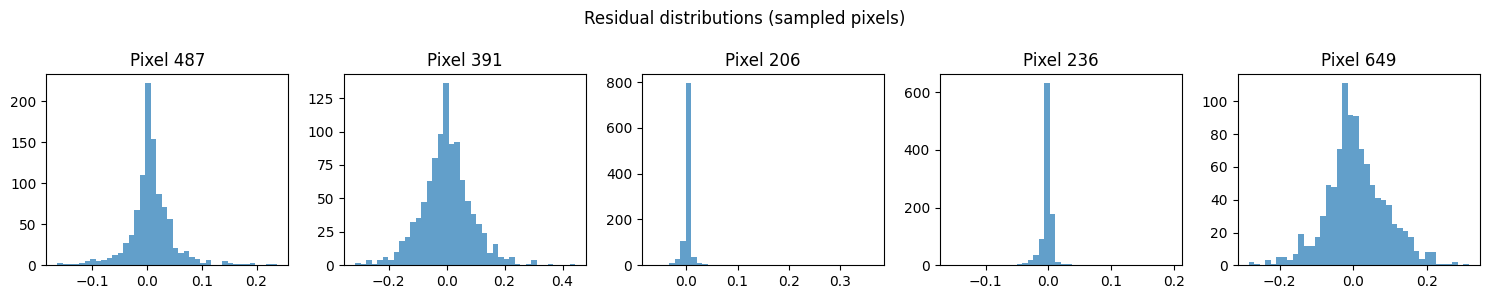

R² of predicting residual (pixel 487) from labels: 0.0053
✓ Residual appears independent of labels (good exogenous noise).


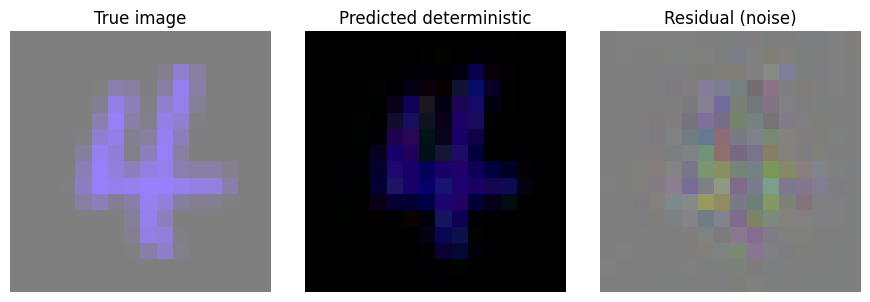


2. COUNTERFACTUAL CONSISTENCY SCORES
----------------------------------------


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


Consistency Scores:
  digit_variance: 0.001288
  color_variance: 0.000299
  noise_corr: 1.000000

3. COLOR HUE ANALYSIS
-------------------------
Mean pairwise JS divergence over hue histograms: 0.1376

4. VISUAL COUNTERFACTUAL SWEEP
-----------------------------------


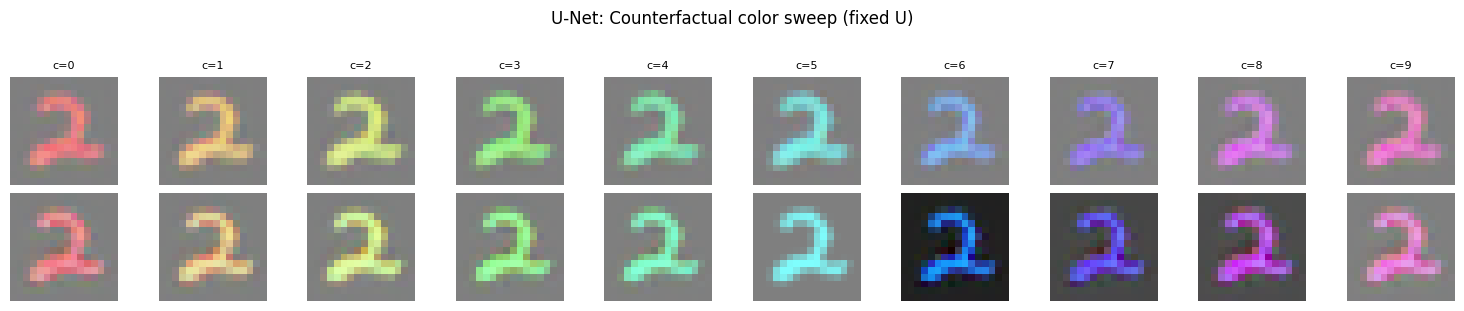


5. SUMMARY INTERPRETATION
------------------------------
Residual Independence:
Residuals are independent of labels (good)

Counterfactual Consistency:
Digit shape preserved across colors (good)
Low color sensitivity (needs improvement)
Noise component is stable (excellent)

Color Hue Diversity: 0.1376
Moderate color diversity (acceptable)

DIAGNOSTICS COMPLETE


In [11]:
# === Load trained artifacts for selected dataset and run diagnostics ===
import os, torch

# 0) Pick the dataset selected in your earlier widget
DATA_DIR = DATASETS[SELECT]
print(f"📦 Using dataset: {DATA_DIR}")

# 1) Load low/high-level samples
Dll_samples = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"))
Dhl_samples = torch.load(os.path.join(DATA_DIR, "dhl_samples.pkl"))

# 2) Import ImageColorizerUNet from your training module
from cmnist_train import ImageColorizerUNet

# 3) Load trained U-Net weights
ll_state_path = os.path.join(DATA_DIR, "ll_model_unet.pth")
assert os.path.isfile(ll_state_path), f"❌ Missing {ll_state_path} — train first."
ll_model = ImageColorizerUNet(norm_type="bn")
ll_model.load_state_dict(torch.load(ll_state_path, map_location="cpu"))
ll_model.eval()
print("✅ Loaded U-Net weights.")

# 4) Load low-level residuals
U_ll_path = os.path.join(DATA_DIR, "U_ll_hat.pkl")
assert os.path.isfile(U_ll_path), f"❌ Missing {U_ll_path} — train first."
U_ll_hat = torch.load(U_ll_path)
print("✅ Loaded U_ll_hat residuals.")

# 5) Extract observational tuples
def _get_obs_tuple(D):
    return D.get("obs") or D.get(None) or next(iter(D.values()))

ll_obs_data_tuple = _get_obs_tuple(Dll_samples)
hl_obs_data = Dhl_samples.get("obs", next(iter(Dhl_samples.values())))

print("Observational data defined:")
imgs, shapes, digs, cols = ll_obs_data_tuple
print(f"  - Low-level:  images {tuple(imgs.shape)}, shapes {tuple(shapes.shape)}, digits {tuple(digs.shape)}, colors {tuple(cols.shape)}")
print(f"  - High-level: {tuple(hl_obs_data.shape)}")

# 6) Run diagnostics
results = comprehensive_counterfactual_diagnostics(
    ll_obs_data_tuple,
    ll_model,     # trained U-Net from this dataset
    U_ll_hat,     # residuals (U_ll_hat.pkl)
    num_samples=5,
    bins=36,
    v_thresh=0.1,
)
